# AI Agent Workshop — Day 1
## Introduction to Agentified AI/ML Applications with the Anthropic Claude Stack

## How to use this notebook

1. Read the concept sections.
2. Run the visualization cells.
3. Inspect and modify the code examples.
4. Discuss how each design pattern maps to the Day 2 challenge.

Throughout the notebook, we move from:

**LLM application → tool-using system → agentic workflow → deployable AI/ML application**

## Learning Goals

By the end of this notebook, students should be able to:

- explain what makes an application *agentified* rather than just *prompt-based*,
- identify core design patterns for AI/ML agents,
- map those patterns onto the Anthropic Claude ecosystem,
- prototype a simple tool-using agent,
- reason about evaluation, safety, observability, and deployment trade-offs,
- prepare to extend an agentic application into a reproducible ML pipeline using DVC.

## Why "agentified" AI/ML applications?

A traditional ML application often follows a relatively fixed path:

> input → feature processing → model inference → output

An **agentified** application still uses models, but adds a new capability:

> the system can decide *what to do next*.

That usually means some combination of:

- selecting tools,
- retrieving external knowledge,
- decomposing tasks,
- checking its own outputs,
- maintaining state across steps,
- deciding when to ask for clarification,
- deciding when to stop.

This makes agentified systems especially useful for **messy, real-world tasks** where a single model call is not enough.

### Use Case: Civic Service Routing (Kitchener-Waterloo)

The challenge is to build an AI-powered assistant that helps residents understand which level of government (City, Region, Province, or Federal) is responsible for a service and guides them through the correct next steps.

> *"Who do I contact about garbage pickup?"*

A plain chatbot might answer: *"Garbage pickup is usually handled by your municipality."*

An agentified civic assistant might instead:
1. inspect the question,
2. determine whether the service is municipal, regional, provincial, or federal,
3. consult trusted service sources,
4. cite the relevant jurisdiction,
5. recommend the next action.

## Environment Setup

**Before running this notebook:** make sure you have a `.env` file in the project root containing:
```
ANTHROPIC_API_KEY=sk-ant-...
```
See `notebooks/Claude_API_Setup.ipynb` for step-by-step setup instructions.

In [1]:
# Install dependencies (run once if needed)
# %pip install -q anthropic python-dotenv pandas matplotlib networkx

In [2]:
import os
import json
import warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import networkx as nx
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

# Load ANTHROPIC_API_KEY from .env — no hardcoded keys, no getpass prompts
ROOT = Path.cwd()
while not (ROOT / 'data').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

load_dotenv(ROOT / '.env')

api_key = os.getenv('ANTHROPIC_API_KEY')
if api_key:
    print(f'API key loaded from .env  (sk-ant-...{api_key[-6:]})')
else:
    print('WARNING: ANTHROPIC_API_KEY not found — add it to .env in the project root')

API key loaded from .env  (sk-ant-...xQgAAA)


In [3]:
import anthropic

CLAUDE_AVAILABLE = False
try:
    client = anthropic.Anthropic(api_key=os.getenv('ANTHROPIC_API_KEY'))
    CLAUDE_AVAILABLE = True
    print('Claude client initialized — ready to build.')
except Exception as exc:
    print(f'Claude client not available: {exc}')
    print('Code cells will show expected output in comments.')

MODEL = 'claude-sonnet-4-6'

Claude client initialized — ready to build.


## The Anthropic Claude Stack: A Practical Mental Model

For teaching purposes, it helps to separate the stack into layers.

### Layer 1 — Models
Claude models handle reasoning, generation, multimodal understanding, and long-context processing.

| Model | Speed | Best for |
|-------|-------|----------|
| `claude-haiku-4-5-20251001` | Fastest | Simple lookups, classifications |
| `claude-sonnet-4-6` | Fast | Main agent tasks (our default) |
| `claude-opus-4-7` | Slower | Complex multi-step reasoning |

### Layer 2 — APIs and SDKs
The Anthropic Python SDK gives you a developer interface: `client.messages.create(...)`.

### Layer 3 — Tools
The model can use tools such as:
- custom function calls (our workshop focus),
- retrieval over local or external data,
- code execution,
- domain-specific APIs.

### Layer 4 — Agent Frameworks
When your workflow goes beyond one model call, frameworks help structure agent behavior (tool loop, state, memory).

### Layer 5 — Production Infrastructure
For deployment, scaling, sessions, memory, evaluation, and observability.

### Learning Rule of Thumb
1. Prompting and outputs
2. Tool use
3. Stateful workflows
4. Multi-step agents
5. Evaluation and deployment

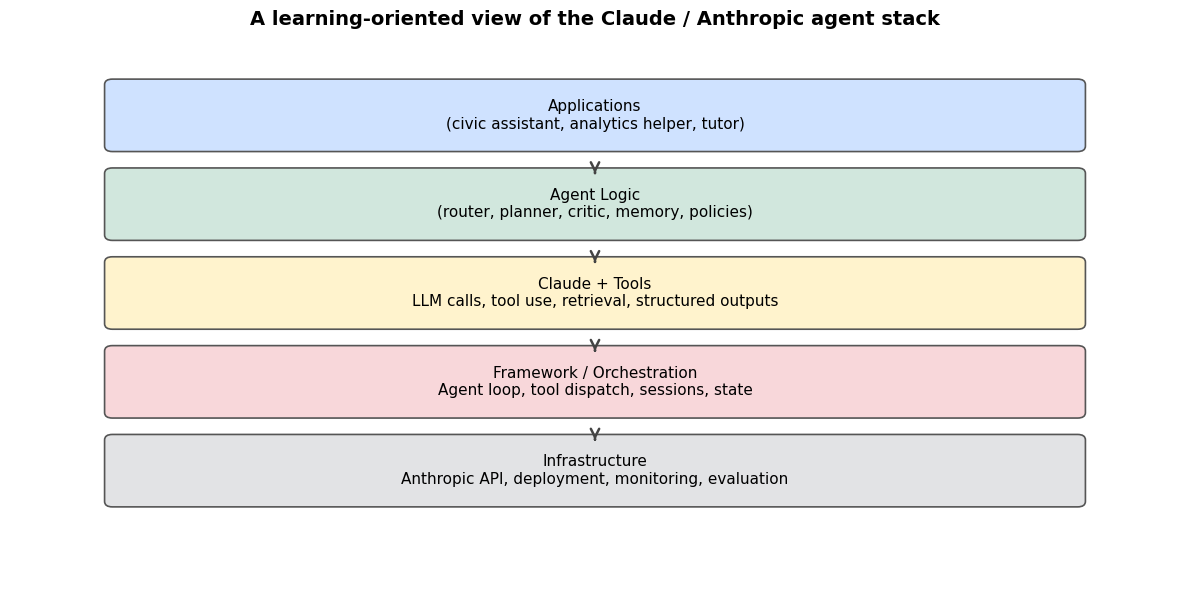

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis('off')

layers = [
    (1, 6.3, 10, 1.0, 'Applications\n(civic assistant, analytics helper, tutor)'),
    (1, 5.0, 10, 1.0, 'Agent Logic\n(router, planner, critic, memory, policies)'),
    (1, 3.7, 10, 1.0, 'Claude + Tools\nLLM calls, tool use, retrieval, structured outputs'),
    (1, 2.4, 10, 1.0, 'Framework / Orchestration\nAgent loop, tool dispatch, sessions, state'),
    (1, 1.1, 10, 1.0, 'Infrastructure\nAnthropic API, deployment, monitoring, evaluation')
]

colors = ['#cfe2ff', '#d1e7dd', '#fff3cd', '#f8d7da', '#e2e3e5']
for (x, y, w, h, label), color in zip(layers, colors):
    patch = FancyBboxPatch((x, y), w, h,
                           boxstyle='round,pad=0.03,rounding_size=0.08',
                           facecolor=color, edgecolor='#555', linewidth=1.2)
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=11)

for y1, y2 in [(6.0, 5.95), (4.7, 4.65), (3.4, 3.35), (2.1, 2.05)]:
    ax.add_patch(FancyArrowPatch((6, y1), (6, y2),
                                 arrowstyle='->', mutation_scale=15, lw=1.8, color='#444'))

plt.title('A learning-oriented view of the Claude / Anthropic agent stack', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## From LLM App to Agent: What Changes?

| Stage | Typical behavior | Limitation |
|---|---|---|
| 1. Prompted LLM app | Single response from one prompt | No external action or verification |
| 2. Tool-using app | Calls APIs or functions | Still mostly linear |
| 3. Agentic workflow | Chooses next steps dynamically | More complexity to manage |
| 4. Multi-agent system | Specialized agents coordinate | Harder evaluation and debugging |
| 5. Production agent platform | Monitoring, memory, governance, deployment | Requires engineering discipline |

**Key insight:** "Agent" is not a magic label. An agent is useful only when there is a meaningful **decision process** over actions, tools, or subgoals.

## Core AI/ML Design Patterns for Agentified Systems

### 1. Router pattern
A model classifies the request and chooses a path.
*Example:* Is the resident asking about waste, roads, licensing, childcare, or taxes?

### 2. Retrieval + generation pattern
The system retrieves trusted documents before answering.
*Example:* Look up service pages from City, Region, Province, or Federal government.

### 3. Tool-calling pattern
The model decides when to call functions or APIs.
*Example:* Call `lookup_service_owner(service_name)` or `suggest_next_steps(service_name)`.

### 4. Planner-worker pattern
One component decomposes the task; others perform the work.
*Example:* Planner: "Identify service → find jurisdiction → gather next steps → draft answer."

### 5. Critique / verify pattern
A second pass checks the answer for confidence, grounding, and safety.
*Example:* Did the assistant cite the right jurisdiction? Did it overstate certainty?

### 6. Memory / state pattern
The system uses persistent or session state.
*Example:* Remember that the resident already asked about their address.

### 7. Human-in-the-loop pattern
The workflow escalates uncertain cases.
*Example:* When multiple jurisdictions share responsibility, ask a clarifying question.

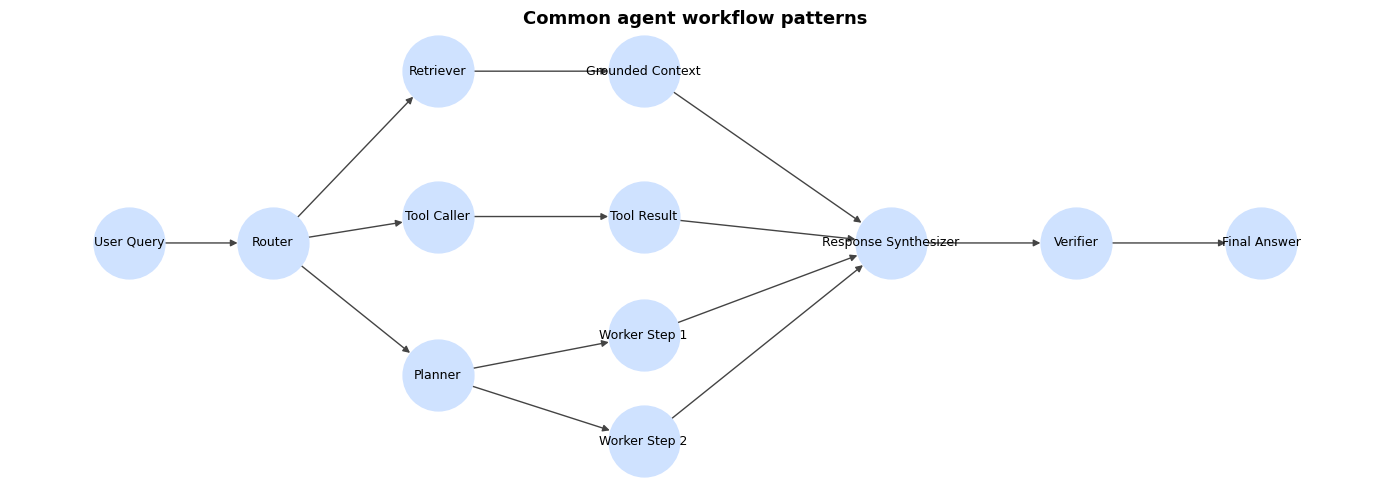

In [5]:
import networkx as nx

G = nx.DiGraph()
edges = [
    ('User Query', 'Router'),
    ('Router', 'Retriever'),
    ('Router', 'Tool Caller'),
    ('Router', 'Planner'),
    ('Retriever', 'Grounded Context'),
    ('Tool Caller', 'Tool Result'),
    ('Planner', 'Worker Step 1'),
    ('Planner', 'Worker Step 2'),
    ('Grounded Context', 'Response Synthesizer'),
    ('Tool Result', 'Response Synthesizer'),
    ('Worker Step 1', 'Response Synthesizer'),
    ('Worker Step 2', 'Response Synthesizer'),
    ('Response Synthesizer', 'Verifier'),
    ('Verifier', 'Final Answer'),
]
G.add_edges_from(edges)

pos = {
    'User Query': (0, 0), 'Router': (1.4, 0),
    'Retriever': (3, 1.3), 'Tool Caller': (3, 0.2), 'Planner': (3, -1.0),
    'Grounded Context': (5, 1.3), 'Tool Result': (5, 0.2),
    'Worker Step 1': (5, -0.7), 'Worker Step 2': (5, -1.5),
    'Response Synthesizer': (7.4, 0), 'Verifier': (9.2, 0), 'Final Answer': (11.0, 0),
}

plt.figure(figsize=(14, 5))
nx.draw_networkx(G, pos=pos, with_labels=True, node_size=2600, font_size=9,
                 node_color='#cfe2ff', edge_color='#444', arrows=True)
plt.title('Common agent workflow patterns', fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## First Claude Call

We start with the simplest possible interaction: a single model call with no tools.
This is **not yet** an agent — it is just a useful baseline.

In [6]:
if CLAUDE_AVAILABLE:
    message = client.messages.create(
        model=MODEL,
        max_tokens=512,
        messages=[{
            'role': 'user',
            'content': 'In 4 bullet points, explain what makes an AI application agentic.'
        }]
    )
    print(message.content[0].text)
else:
    print('(Claude API not available — add ANTHROPIC_API_KEY to .env)')

Here are 4 key characteristics that make an AI application agentic:

• **Autonomous Decision-Making** — The AI can independently make decisions and take actions to pursue a goal without requiring human input or approval at every step.

• **Tool Use & Environment Interaction** — The AI can interact with external tools, APIs, databases, or systems (e.g., browsing the web, writing code, sending emails) to affect the real world beyond just generating text.

• **Goal-Directed Planning** — The AI can break down complex objectives into sub-tasks, reason about sequences of steps, and adapt its plan dynamically based on new information or outcomes.

• **Memory & Feedback Loops** — The AI maintains context across multiple steps and uses the results of previous actions to inform future decisions, allowing it to course-correct and iterate toward its goal.


### Discussion

Why begin here?

Because we need a baseline before complexity is added. A good pedagogical sequence is:
1. Single call
2. Structured call
3. Tool call
4. Loop
5. Multi-step workflow
6. Evaluation

That sequence makes debugging much easier.

## Adding Structure: From Free Text to Machine-Usable Outputs

Most real AI/ML systems should not stop at "nice text." They need structured outputs that downstream code can consume.

For the civic assistant, a useful intermediate representation might be:
- `service`
- `jurisdiction`
- `confidence`
- `requires_clarification`
- `recommended_next_step`

> LLMs are much easier to integrate when they produce typed, constrained outputs.

With Claude, we enforce structured JSON output via the **system prompt** — instructing the model to return only a valid JSON object matching our schema.

In [7]:
structured_system_prompt = '''You are a public-service classification assistant.

Return ONLY a valid JSON object with exactly these fields:
{
  "service": "string",
  "jurisdiction": "City | Region | Province | Federal | Unknown",
  "confidence": <float 0.0-1.0>,
  "requires_clarification": <true|false>,
  "recommended_next_step": "string"
}

No markdown, no explanation — only the JSON object.'''

if CLAUDE_AVAILABLE:
    message = client.messages.create(
        model=MODEL,
        max_tokens=256,
        system=structured_system_prompt,
        messages=[{
            'role': 'user',
            'content': 'Classify this resident question: "Who do I contact about garbage pickup?"'
        }]
    )
    raw = message.content[0].text
    parsed = json.loads(raw)
    print(json.dumps(parsed, indent=2))
else:
    # Expected output:
    parsed = {
        'service': 'garbage pickup',
        'jurisdiction': 'Region',
        'confidence': 0.85,
        'requires_clarification': False,
        'recommended_next_step': 'Contact the Region of Waterloo Waste Management.'
    }
    print(json.dumps(parsed, indent=2))

{
  "service": "Waste Collection / Garbage Pickup",
  "jurisdiction": "City",
  "confidence": 0.92,
  "requires_clarification": false,
  "recommended_next_step": "Direct the resident to their local municipal public works or waste management department, typically found on the city's official website under 'Sanitation' or 'Public Works'."
}


## Tool Use: The First Real Step Toward Agentified Behavior

Now we give the model access to an external function.

In production, that function might query a municipal service registry, an open dataset,
a search index, a CRM, or a contact directory. For teaching, a Python dictionary is enough.

### How Claude Tool Calling Works

With the Anthropic SDK, you declare tools as a list of dicts with `name`, `description`, and `input_schema`.
Claude returns `stop_reason='tool_use'` when it wants to call a tool, and you loop back with the result.

In [8]:
SERVICE_OWNERSHIP = {
    'garbage pickup': {
        'jurisdiction': 'Region',
        'contact': 'Region of Waterloo Waste Management',
        'next_step': 'Check your collection schedule at regionofwaterloo.ca/waste.'
    },
    'childcare licensing': {
        'jurisdiction': 'Province',
        'contact': 'Ontario Ministry of Education — Child Care Licensing',
        'next_step': 'Review Ontario childcare licensing requirements online.'
    },
    'property tax billing': {
        'jurisdiction': 'City',
        'contact': 'City of Kitchener Revenue Division',
        'next_step': 'Contact the City Revenue Division or visit kitchener.ca/taxes.'
    },
}

def lookup_service_owner(service_name: str) -> dict:
    key = service_name.strip().lower()
    result = SERVICE_OWNERSHIP.get(key)
    if result is None:
        return {
            'jurisdiction': 'Unknown',
            'contact': 'Unknown',
            'next_step': 'Search the relevant government website or call 311.'
        }
    return result

# Test the tool directly
print(lookup_service_owner('garbage pickup'))

{'jurisdiction': 'Region', 'contact': 'Region of Waterloo Waste Management', 'next_step': 'Check your collection schedule at regionofwaterloo.ca/waste.'}


In [9]:
# ── Tool declaration (Anthropic format) ────────────────────────────────────────
tool_declarations = [
    {
        'name': 'lookup_service_owner',
        'description': (
            'Looks up which level of government is responsible for a public service '
            'and suggests next steps for the resident.'
        ),
        'input_schema': {
            'type': 'object',
            'properties': {
                'service_name': {
                    'type': 'string',
                    'description': 'Name of the public service, e.g. "garbage pickup" or "property tax billing".'
                }
            },
            'required': ['service_name']
        }
    }
]

print(f'Tool declared: {tool_declarations[0]["name"]}')

Tool declared: lookup_service_owner


In [10]:
# Step 1: Ask Claude a question with the tool available
question = 'A resident asks: "Who do I contact about garbage pickup?"'

if CLAUDE_AVAILABLE:
    response = client.messages.create(
        model=MODEL,
        max_tokens=512,
        tools=tool_declarations,
        messages=[{'role': 'user', 'content': question}]
    )

    print(f'Stop reason: {response.stop_reason}')
    print(f'Content blocks: {len(response.content)}')
    for block in response.content:
        print(f'  type={block.type}', end='')
        if block.type == 'tool_use':
            print(f'  name={block.name}  input={block.input}')
        else:
            print()
else:
    print('stop_reason: tool_use')
    print('Claude selected: lookup_service_owner({"service_name": "garbage pickup"})')

Stop reason: tool_use
Content blocks: 2
  type=text
  type=tool_use  name=lookup_service_owner  input={'service_name': 'garbage pickup'}


### Understanding Claude's Tool Call Response

When `stop_reason == 'tool_use'`, Claude is saying:

> *"I need to call `lookup_service_owner(service_name='garbage pickup')` before I can answer."*

**What has NOT happened yet:**
- ✅ Claude has **proposed** a function call
- ❌ Your Python code has **not** executed the tool
- ❌ No real lookup has happened

**This stage represents: tool selection and argument generation — not tool execution.**

The complete flow is:
1. User asks a question
2. Claude decides a tool is needed
3. Claude emits a `tool_use` block with name + input
4. **Your application code** executes the real function
5. **Your application** sends back a `tool_result` block
6. Claude converts the result into a natural-language answer

In [11]:
# Step 2: Extract the tool call and execute it
if CLAUDE_AVAILABLE:
    tool_use_block = next(
        (block for block in response.content if block.type == 'tool_use'), None
    )

    if tool_use_block:
        fn_name = tool_use_block.name
        fn_args = dict(tool_use_block.input)
        tool_use_id = tool_use_block.id

        print(f'Tool selected: {fn_name}')
        print(f'Arguments:     {fn_args}')

        # Execute our Python function
        tool_result = lookup_service_owner(**fn_args)
        print(f'Tool result:   {tool_result}')
    else:
        print('No tool call returned.')
        tool_use_id = None
        tool_result = {}
else:
    fn_name = 'lookup_service_owner'
    fn_args = {'service_name': 'garbage pickup'}
    tool_use_id = 'fake-id-001'
    tool_result = SERVICE_OWNERSHIP['garbage pickup']
    print(f'Tool result: {tool_result}')

Tool selected: lookup_service_owner
Arguments:     {'service_name': 'garbage pickup'}
Tool result:   {'jurisdiction': 'Region', 'contact': 'Region of Waterloo Waste Management', 'next_step': 'Check your collection schedule at regionofwaterloo.ca/waste.'}


In [12]:
# Step 3: Send the tool result back to Claude for answer synthesis
if CLAUDE_AVAILABLE and tool_use_id:
    followup = client.messages.create(
        model=MODEL,
        max_tokens=512,
        tools=tool_declarations,
        messages=[
            # Original user question
            {'role': 'user', 'content': question},
            # Claude's tool call response
            {'role': 'assistant', 'content': response.content},
            # Our tool result
            {
                'role': 'user',
                'content': [{
                    'type': 'tool_result',
                    'tool_use_id': tool_use_id,
                    'content': json.dumps(tool_result)
                }]
            }
        ]
    )

    print('=== Claude\'s final answer ===')
    print(followup.content[0].text)
else:
    print('Expected output:')
    print('Garbage pickup is managed by the Region of Waterloo. '
          'Contact the Region of Waterloo Waste Management and '
          'check your collection schedule at regionofwaterloo.ca/waste.')

=== Claude's final answer ===
Great news! Here's what I found for the resident:

🗑️ **Garbage Pickup**
- **Responsible Jurisdiction:** Region
- **Who to Contact:** **Region of Waterloo Waste Management**
- **Next Step:** Check your collection schedule at **regionofwaterloo.ca/waste**

You can visit that website to find your pickup schedule, report a missed collection, or get more information about waste management services. If you need further assistance, feel free to ask! 😊


### Why This Pattern Matters

This three-step loop is the core of tool-using agent behavior:

1. **Claude decides** what tool to call
2. **Your application executes** the tool (external state, real data, error handling)
3. **Claude synthesizes** the result into a user-facing answer

Once you understand this loop, you are ready to move from "LLM application" to "agentified AI/ML application."

## A Simple Single-Agent Architecture

The most teachable first agent is often **not** multi-agent.

A strong first architecture is:
1. Classify the question
2. Retrieve or look up trusted information
3. Synthesize an answer
4. Verify whether the answer is grounded and actionable

This is enough to learn most core concepts without adding unnecessary orchestration complexity.

In [13]:
def civic_agent_pipeline(question: str) -> dict:
    """3-step pipeline: extract service → lookup → synthesise answer."""

    # Step 1: Extract service label from the question
    extraction = client.messages.create(
        model=MODEL,
        max_tokens=64,
        system='Extract the main public service being asked about. Return only a short lowercase label — nothing else.',
        messages=[{'role': 'user', 'content': question}]
    )
    service = extraction.content[0].text.strip().lower()

    # Step 2: Use our local lookup tool
    lookup = lookup_service_owner(service)

    # Step 3: Synthesize a grounded, resident-facing answer
    answer_prompt = (
        f'Resident question: {question}\n'
        f'Identified service: {service}\n'
        f'Lookup result: {json.dumps(lookup)}\n\n'
        'Write a concise public-facing answer. '
        'State the jurisdiction, who to contact, and the next step. '
        'If certainty is limited, say so.'
    )
    answer_msg = client.messages.create(
        model=MODEL,
        max_tokens=256,
        messages=[{'role': 'user', 'content': answer_prompt}]
    )

    return {'service': service, 'lookup': lookup, 'answer': answer_msg.content[0].text}


if CLAUDE_AVAILABLE:
    demo = civic_agent_pipeline('Who do I contact about garbage pickup?')
    print(f'Service:  {demo["service"]}')
    print(f'Lookup:   {demo["lookup"]}')
    print(f'Answer:   {demo["answer"]}')
else:
    print('(Requires ANTHROPIC_API_KEY in .env)')

Service:  waste collection
Lookup:   {'jurisdiction': 'Unknown', 'contact': 'Unknown', 'next_step': 'Search the relevant government website or call 311.'}
Answer:   **Garbage Pickup / Waste Collection**

Based on the information available, the specific jurisdiction and direct contact for your waste collection service could not be determined.

**Recommended next steps:**
- **Call 311** – This is the most reliable option for local government services in many areas.
- **Search your local government website** (city, county, or municipality) for waste collection or sanitation department contact details.

If you can share your city or county, a more specific answer may be possible.


## Where Retrieval Fits In

For a real municipal assistant, a hardcoded dictionary is not enough.

We need retrieval over trusted sources such as:
- City of Kitchener service pages
- Region of Waterloo service pages
- Ontario service pages
- Government of Canada service pages

That gives us a key design principle:

> **Use the model for interpretation and synthesis.**
> **Use tools and retrieval for facts, records, and operational truth.**

This is one of the most important engineering lessons in agent design.

In Day 2, we build exactly this — a keyword-retrieval layer over the `service_catalog.csv`,
injected as context into Claude's prompt (Tier 2), or accessed via tools Claude calls directly (Tier 3).

## Multi-Agent Systems: When Are They Worth It?

Students often want to jump straight to "multi-agent." That is understandable,
but premature complexity is a common mistake.

Use multiple agents only when there is a **clear division of labor**, for example:
- **Router agent**: classifies the request
- **Research agent**: gathers relevant service evidence
- **Policy agent**: checks wording and compliance
- **Response agent**: drafts the final resident-facing answer
- **Evaluator agent**: scores confidence and grounding

**Rule:** If one well-designed agent with tools can do the job, start there first.

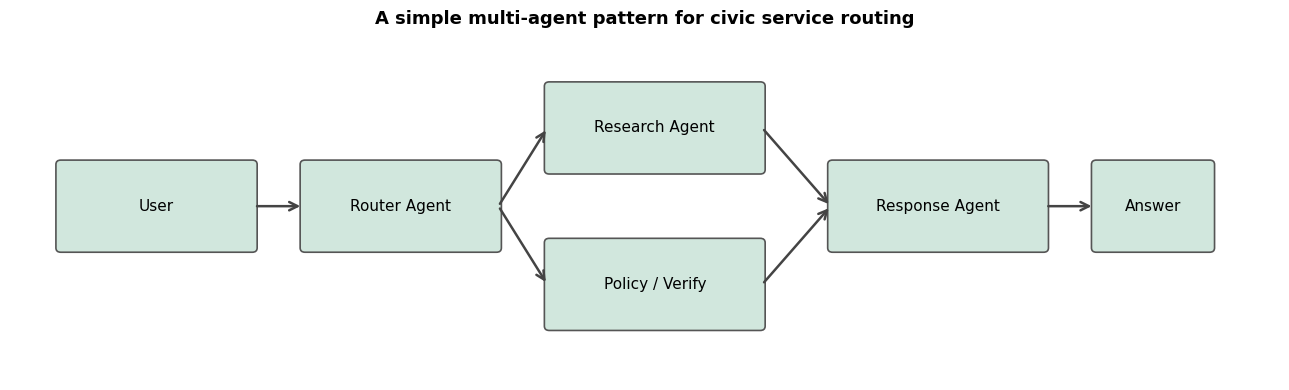

In [14]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis('off')

boxes = [
    (0.5, 1.5, 2.0, 1.0, 'User'),
    (3.0, 1.5, 2.0, 1.0, 'Router Agent'),
    (5.5, 2.4, 2.2, 1.0, 'Research Agent'),
    (5.5, 0.6, 2.2, 1.0, 'Policy / Verify'),
    (8.4, 1.5, 2.2, 1.0, 'Response Agent'),
    (11.1, 1.5, 1.2, 1.0, 'Answer'),
]
for x, y, w, h, label in boxes:
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                                boxstyle='round,pad=0.03,rounding_size=0.05',
                                facecolor='#d1e7dd', edgecolor='#555', linewidth=1.2))
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=11)

for start, end in [
    ((2.5, 2.0), (3.0, 2.0)), ((5.0, 2.0), (5.5, 2.9)),
    ((5.0, 2.0), (5.5, 1.1)), ((7.7, 2.9), (8.4, 2.0)),
    ((7.7, 1.1), (8.4, 2.0)), ((10.6, 2.0), (11.1, 2.0))
]:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=15, lw=1.8, color='#444'))

plt.title('A simple multi-agent pattern for civic service routing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Evaluation

Agentic systems can look impressive while being unreliable.

For the civic assistant, evaluation should include at least:

- **Jurisdiction accuracy** — Did the system identify the correct level of government?
- **Grounding quality** — Was the answer supported by trustworthy sources?
- **Actionability** — Did the response give a clear next step?
- **Format compliance** — Did the output match the required JSON schema?
- **Calibration** — Did the assistant express uncertainty when evidence was weak?

In [15]:
evaluation_stub = pd.DataFrame([
    {
        'question': 'Who do I contact about garbage pickup?',
        'true_jurisdiction': 'Region',
        'predicted_jurisdiction': None,
        'grounded': None,
        'actionable': None,
        'notes': '',
    },
    {
        'question': 'Is childcare a city or provincial service?',
        'true_jurisdiction': 'Province',
        'predicted_jurisdiction': None,
        'grounded': None,
        'actionable': None,
        'notes': '',
    },
])
evaluation_stub

,question,true_jurisdiction,predicted_jurisdiction,grounded,actionable,notes
0,Who do I contact about garbage pickup?,Region,None,None,None,
1,Is childcare a city or provincial service?,Province,None,None,None,


## Common Failure Modes in Agentified Systems

### Failure mode 1: Hallucinated authority
The model sounds confident about the wrong jurisdiction.

### Failure mode 2: Tool misuse
The model calls a tool unnecessarily or with poor arguments.

### Failure mode 3: Retrieval mismatch
The retrieved passage is real but not relevant to the user's exact question.

### Failure mode 4: Over-engineering
A multi-agent architecture is used where a single grounded workflow would be better.

### Failure mode 5: Poor state management
The system loses track of prior clarification, context, or user intent.

### Failure mode 6: No evaluation harness
The application looks good in demos but performs inconsistently in practice.

## Connection to Day 2: The Municipal Challenge

The Day 2 challenge asks students to build:

> An AI-powered assistant that helps residents determine which level of government is responsible for a service and what to do next.

That challenge naturally requires: classification, retrieval, tool use, uncertainty handling, explainability, and evaluation.

### Recommended architecture progression

| Version | What to build |
|---------|---------------|
| **Tier 1** | Single agent, structured output, no external data — baseline |
| **Tier 2** | Add keyword retrieval over service catalog, inject as context (RAG) |
| **Tier 3** | Add Claude tool calling — 3 tools, agentic loop, tool trace |

## Looking Ahead: Why DVC Belongs After the Agent Lesson

Once students move beyond a demo, they need reproducibility for:
- indexed source data
- evaluation datasets
- prompt templates and schemas
- pipeline stages and metrics

> **Agent design solves the interaction problem.**
> **ML pipelines solve the reproducibility problem.**

## Reflection Prompts

1. What is the smallest useful definition of an AI agent?
2. When should you prefer retrieval over model memory?
3. When is a function call better than asking the model to answer directly?
4. What does a "grounded answer" mean in a civic context?
5. Why might a single-agent system outperform a multi-agent system on a student project?
6. Which parts of today's architecture should become DVC pipeline stages in Day 2?

## Mini-Exercises

### Exercise A — Prompt to schema
Modify the system prompt in the structured call cell so the model also returns a `source_url` field.

### Exercise B — Build one tool
Add a second tool called `suggest_next_steps(service_name)` to the tool declarations and wire it up.

### Exercise C — Add a verifier
Create a second Claude call that checks whether the answer is grounded and appropriately cautious.

### Exercise D — Prepare for Day 2
Write down the minimum datasets, APIs, or webpages needed for a real municipal prototype.